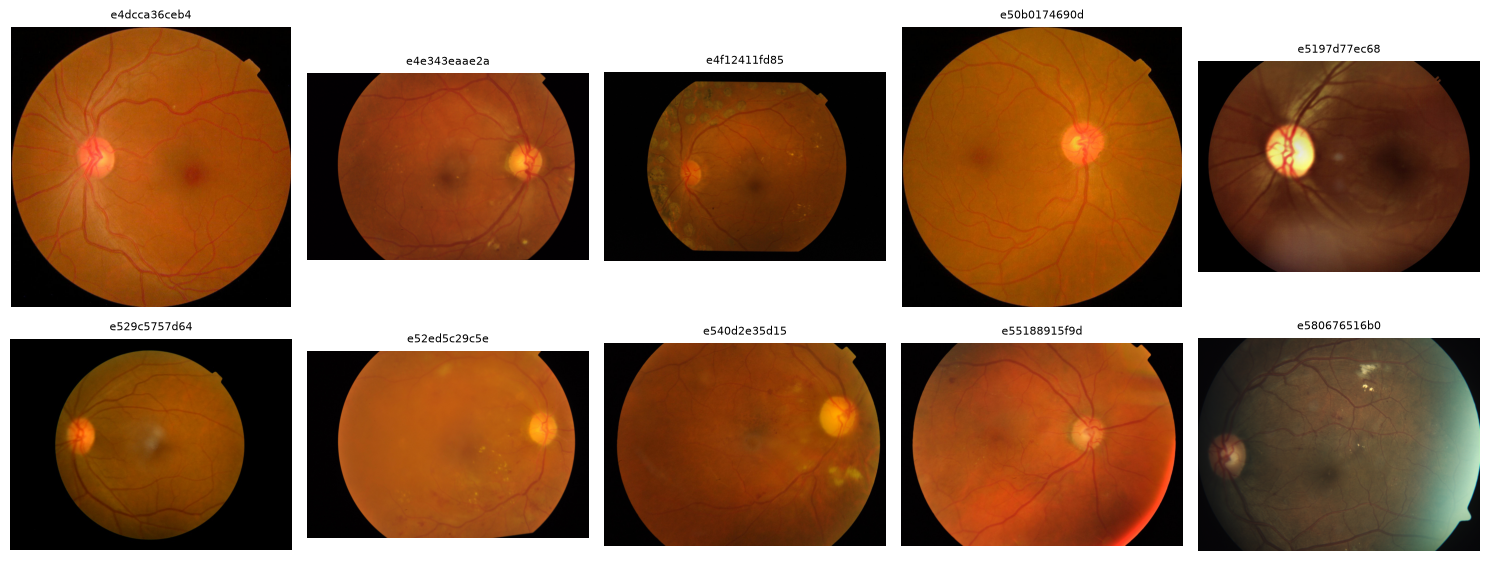

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import os

test_dir = "aptos2019/test_images/test_images"
test_df = pd.read_csv("aptos2019/test.csv")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, img_id in zip(axes.flatten(), test_df["id_code"].head(10)):
    img_path = os.path.join(test_dir, f"{img_id}.png")
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(img_id, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [4]:
import cv2
import numpy as np
from PIL import Image


def crop_fundus(img, threshold=7, pad=0):
    """
    Crop a fundus image to its actual retinal content, regardless of
    whether it's a full circle or a top/bottom-clipped rectangle.
    Thresholds out near-black background, then crops to the bounding box.
    """
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > threshold

    if mask.sum() == 0:
        return img  # degenerate: near-all-black image, skip crop

    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    y0, x0 = max(0, y0 - pad), max(0, x0 - pad)
    y1, x1 = min(img.shape[0], y1 + pad), min(img.shape[1], x1 + pad)

    return img[y0:y1, x0:x1]


def pad_to_square(img, pad_value=0):
    """Pad to a square canvas, content centered, so resize doesn't stretch
    full circles and clipped rectangles by different amounts."""
    h, w = img.shape[:2]
    size = max(h, w)
    top = (size - h) // 2
    bottom = size - h - top
    left = (size - w) // 2
    right = size - w - left
    return cv2.copyMakeBorder(img, top, bottom, left, right,
                               cv2.BORDER_CONSTANT, value=pad_value)


def preprocess_fundus(img_path, out_size=224, threshold=7):
    """Full pipeline: load -> crop to content -> pad to square -> resize."""
    img = np.array(Image.open(img_path).convert("RGB"))
    img = crop_fundus(img, threshold=threshold)
    img = pad_to_square(img)
    img = cv2.resize(img, (out_size, out_size), interpolation=cv2.INTER_AREA)
    return img

Done. Processed 2930 images -> aptos2019/train_images_processed/train_images_processed


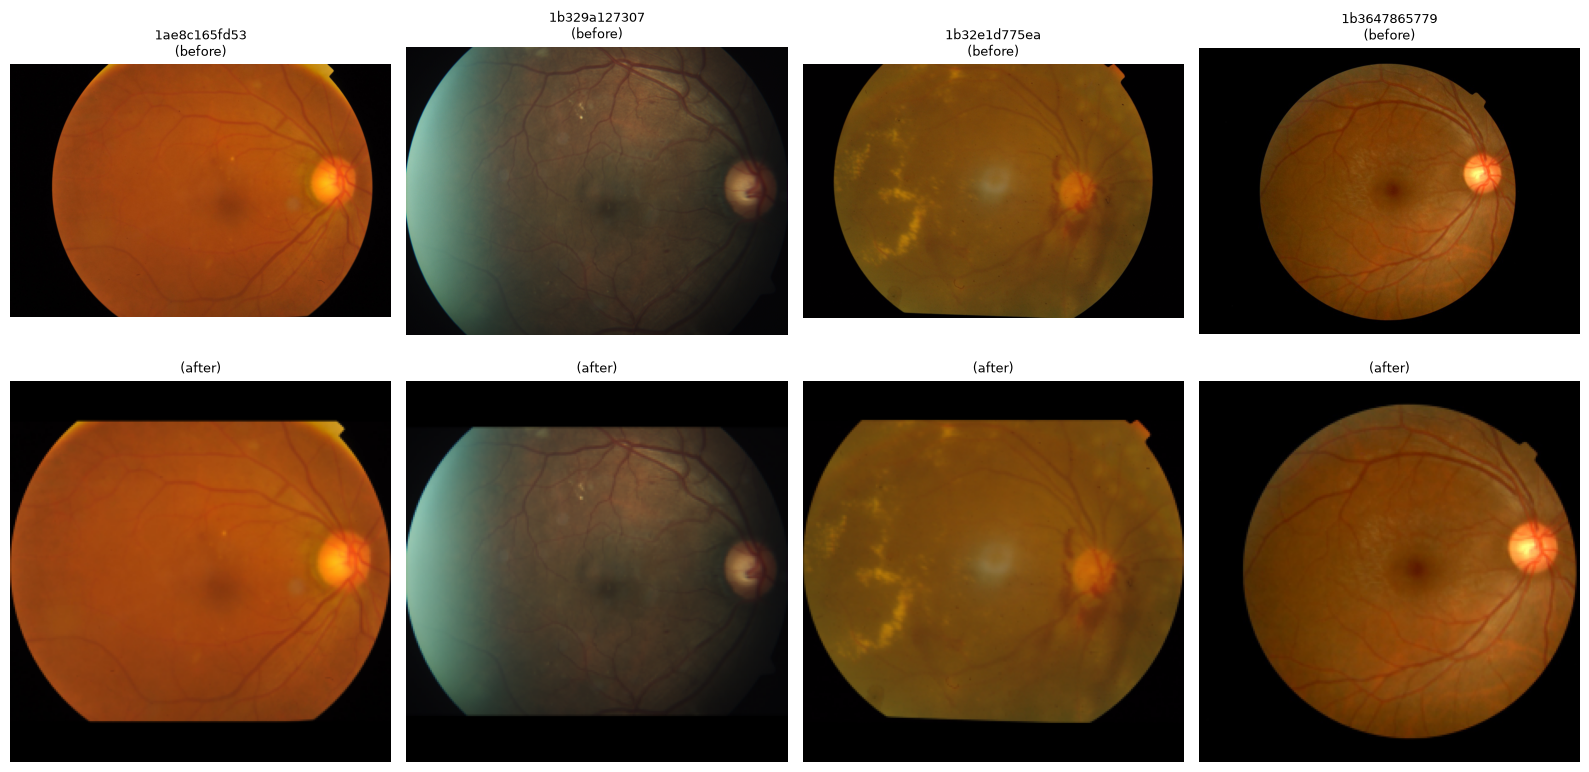

In [6]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

# --- paths ---
train_dir = "aptos2019/train_images/train_images"       # adjust if yours differs
train_csv = "aptos2019/train_1.csv"
out_dir = "aptos2019/train_images_processed/train_images_processed"

os.makedirs(out_dir, exist_ok=True)

train_df = pd.read_csv(train_csv)

# --- process the whole train set, save to a new folder (originals untouched) ---
for img_id in train_df["id_code"]:
    src_path = os.path.join(train_dir, f"{img_id}.png")
    dst_path = os.path.join(out_dir, f"{img_id}.png")

    processed = preprocess_fundus(src_path)
    Image.fromarray(processed).save(dst_path)

print(f"Done. Processed {len(train_df)} images -> {out_dir}")

# --- before/after preview for a few samples ---
sample_ids = train_df["id_code"].head(4).tolist()

fig, axes = plt.subplots(2, len(sample_ids), figsize=(4 * len(sample_ids), 8))

for i, img_id in enumerate(sample_ids):
    before = Image.open(os.path.join(train_dir, f"{img_id}.png"))
    after = Image.open(os.path.join(out_dir, f"{img_id}.png"))

    axes[0, i].imshow(before)
    axes[0, i].set_title(f"{img_id}\n(before)", fontsize=9)
    axes[0, i].axis("off")

    axes[1, i].imshow(after)
    axes[1, i].set_title("(after)", fontsize=9)
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [12]:
import os
import pandas as pd
from PIL import Image

def process_split(img_dir, csv_path, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    df = pd.read_csv(csv_path)

    for img_id in df["id_code"]:
        src_path = os.path.join(img_dir, f"{img_id}.png")
        dst_path = os.path.join(out_dir, f"{img_id}.png")
        processed = preprocess_fundus(src_path)
        Image.fromarray(processed).save(dst_path)

    print(f"Done. Processed {len(df)} images -> {out_dir}")


process_split(
    img_dir="aptos2019/test_images/test_images",
    csv_path="aptos2019/test.csv",
    out_dir="aptos2019/test_images_processed/test_images_processed",
)

process_split(
    img_dir="aptos2019/val_images/val_images",
    csv_path="aptos2019/valid.csv",
    out_dir="aptos2019/val_images_processed/val_images_processed",
)

Done. Processed 366 images -> aptos2019/test_images_processed/test_images_processed
Done. Processed 366 images -> aptos2019/val_images_processed/val_images_processed


In [13]:
import pandas as pd

def make_binary_multiclass(csv_path, out_prefix):
    df = pd.read_csv(csv_path)

    # --- binary: 0 = No DR, 1 = DR detected (any severity) ---
    binary_df = df.copy()
    binary_df["diagnosis"] = (binary_df["diagnosis"] > 0).astype(int)
    binary_df.to_csv(f"{out_prefix}_binary.csv", index=False)

    # --- multiclass: drop No DR cases, keep original severity labels (1-4) ---
    multiclass_df = df[df["diagnosis"] > 0].copy()
    multiclass_df.to_csv(f"{out_prefix}_multiclass.csv", index=False)

    print(f"{out_prefix}: binary={len(binary_df)} rows, "
          f"multiclass={len(multiclass_df)} rows (dropped {len(df) - len(multiclass_df)} No-DR)")

    return binary_df, multiclass_df


train_binary, train_multiclass = make_binary_multiclass("aptos2019/train_1.csv", "aptos2019/train")
test_binary, test_multiclass = make_binary_multiclass("aptos2019/test.csv", "aptos2019/test")
val_binary, val_multiclass = make_binary_multiclass("aptos2019/valid.csv", "aptos2019/valid")

aptos2019/train: binary=2930 rows, multiclass=1496 rows (dropped 1434 No-DR)
aptos2019/test: binary=366 rows, multiclass=167 rows (dropped 199 No-DR)
aptos2019/valid: binary=366 rows, multiclass=194 rows (dropped 172 No-DR)


In [15]:
# remap multiclass labels from {1,2,3,4} to {0,1,2,3} for CrossEntropyLoss,
# applied identically across train/val/test so nothing downstream drifts

for df in [train_multiclass, test_multiclass, val_multiclass]:
    df["diagnosis"] = df["diagnosis"] - 1

# overwrite the CSVs with the remapped labels
train_multiclass.to_csv("aptos2019/train_multiclass.csv", index=False)
test_multiclass.to_csv("aptos2019/test_multiclass.csv", index=False)
val_multiclass.to_csv("aptos2019/valid_multiclass.csv", index=False)

# sanity check
for name, df in [("train", train_multiclass), ("test", test_multiclass), ("valid", val_multiclass)]:
    print(f"{name} label range: {df['diagnosis'].min()} - {df['diagnosis'].max()}")

train label range: 0 - 3
test label range: 0 - 3
valid label range: 0 - 3


In [16]:
label_names = {0: "Mild", 1: "Moderate", 2: "Severe", 3: "Proliferative DR"}

for name, df in [("train_multiclass", train_multiclass),
                  ("test_multiclass", test_multiclass),
                  ("valid_multiclass", val_multiclass)]:
    counts = df["diagnosis"].value_counts().sort_index()
    summary = pd.DataFrame({
        "count": counts,
        "percent": (counts / len(df) * 100).round(1)
    })
    summary["label"] = summary.index.map(label_names)
    print(f"\n{name} (n={len(df)})")
    print(summary[["label", "count", "percent"]])


train_multiclass (n=1496)
                      label  count  percent
diagnosis                                  
0                      Mild    300     20.1
1                  Moderate    808     54.0
2                    Severe    154     10.3
3          Proliferative DR    234     15.6

test_multiclass (n=167)
                      label  count  percent
diagnosis                                  
0                      Mild     30     18.0
1                  Moderate     87     52.1
2                    Severe     17     10.2
3          Proliferative DR     33     19.8

valid_multiclass (n=194)
                      label  count  percent
diagnosis                                  
0                      Mild     40     20.6
1                  Moderate    104     53.6
2                    Severe     22     11.3
3          Proliferative DR     28     14.4
